In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "datasets"

DATASET INFORMATION
Rows: 32561 
Columns: 15 
Column names:
 [1] "age"            "workclass"      "fnlwgt"         "education"     
 [5] "education.num"  "marital.status" "occupation"     "relationship"  
 [9] "race"           "sex"            "capital.gain"   "capital.loss"  
[13] "hours.per.week" "native.country" "income"        

First 6 rows:
  age workclass fnlwgt    education education.num marital.status
1  90         ?  77053      HS-grad             9        Widowed
2  82   Private 132870      HS-grad             9        Widowed
3  66         ? 186061 Some-college            10        Widowed
4  54   Private 140359      7th-8th             4       Divorced
5  41   Private 264663 Some-college            10      Separated
6  34   Private 216864      HS-grad             9       Divorced
         occupation  relationship  race    sex capital.gain capital.loss
1                 ? Not-in-family White Female            0         4356
2   Exec-managerial Not-in-family White Female   


Attaching package: ‘naniar’


The following object is masked from ‘package:skimr’:

    n_complete





MISSING DATA VISUALIZATION BEFORE CLEANING

MISSING DATA VISUALIZATION AFTER CLEANING


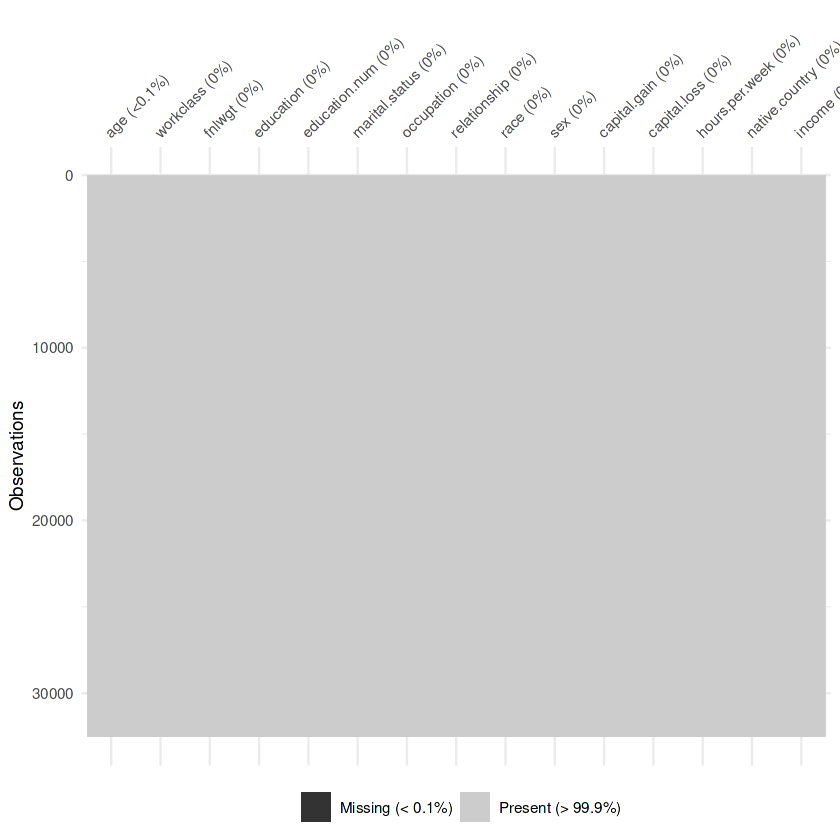


Cleaned dataset saved as: cleaned_adult_data.csv

FINAL LAB 4 SUMMARY
Original rows: 32561 
Original columns: 15 
Cleaned rows: 32561 
Cleaned columns: 15 
Missing values before: 20 
Missing values after: 0 
Invalid age values: 0 
Missing numeric values: 0 
Blank categorical values: 0 
Output file: cleaned_adult_data.csv


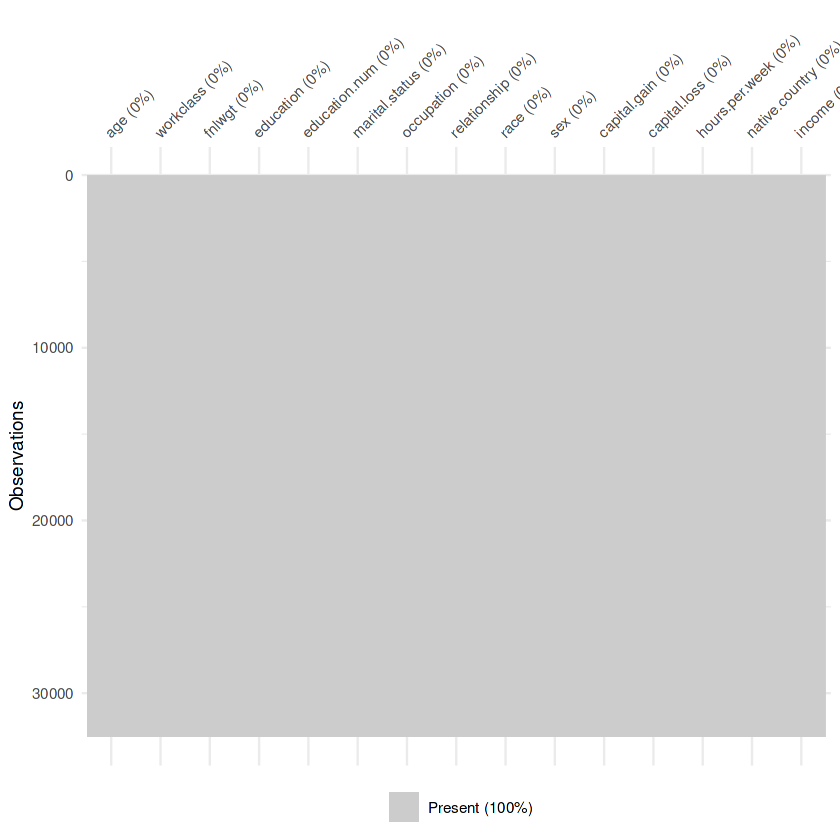

In [3]:
# LAB 4: ADVANCED MISSING DATA HANDLING
# Dataset: UCI Adult Census Income
# Input file: adult.csv

# TASK 0: LOAD AND EXPLORE DATASET

adult <- read.csv("/kaggle/input/datasets/lovishbansal123/adult-census-income/adult.csv", stringsAsFactors = FALSE)

cat("DATASET INFORMATION\n")
cat("Rows:", nrow(adult), "\n")
cat("Columns:", ncol(adult), "\n")
cat("Column names:\n")
print(names(adult))
cat("\nFirst 6 rows:\n")
print(head(adult))
cat("\nStructure:\n")
str(adult)
cat("\nSummary:\n")
print(summary(adult))

# Check required column

if (!"age" %in% names(adult)) {
  stop("age column not found.")
}

# TASK 1: SIMULATE MISSING AND INVALID VALUES
# NA -> missing value
# NaN -> not a number
# "" -> blank string
# age = 999 -> impossible age

set.seed(123)

adult_dirty <- adult
n <- nrow(adult_dirty)

# Select rows for different types of invalid data

na_rows <- sample(1:n, 10)

nan_rows <- sample(
  setdiff(1:n, na_rows),
  10
)

blank_rows <- sample(
  setdiff(1:n, c(na_rows, nan_rows)),
  10
)

invalid_age_rows <- sample(
  setdiff(1:n, c(na_rows, nan_rows, blank_rows)),
  10
)

# Introduce NA into age

adult_dirty$age[na_rows] <- NA

# Introduce NaN into age

adult_dirty$age[nan_rows] <- NaN

# Introduce blank values into a categorical column

categorical_columns <- names(
  adult_dirty[
    sapply(adult_dirty, is.character)
  ]
)

if (length(categorical_columns) > 0) {
  blank_column <- categorical_columns[1]
  adult_dirty[blank_rows, blank_column] <- ""
} else {
  blank_column <- NULL
}

# Introduce impossible age

adult_dirty$age[invalid_age_rows] <- 999

cat("\nSIMULATED INVALID DATA\n")
cat("NA values:", sum(is.na(adult_dirty$age)), "\n")
cat("NaN values:", sum(is.nan(adult_dirty$age)), "\n")

if (!is.null(blank_column)) {
  cat("Blank values in", blank_column, ":", sum(adult_dirty[[blank_column]] == "", na.rm = TRUE), "\n")
}

cat("Impossible age values:", sum(adult_dirty$age == 999, na.rm = TRUE), "\n")

# TASK 2: IDENTIFY MISSING DATA TYPES
# is.na() -> detects NA and NaN
# is.nan() -> detects NaN
# is.null() -> checks whether an object is NULL
# x == "" -> detects blank strings

cat("\nMISSING DATA TYPES\n")

cat("is.na(age):", sum(is.na(adult_dirty$age)), "\n")
cat("is.nan(age):", sum(is.nan(adult_dirty$age)), "\n")
cat("is.null(age):", is.null(adult_dirty$age), "\n")

if (!is.null(blank_column)) {
  cat("Blank strings:", sum(adult_dirty[[blank_column]] == "", na.rm = TRUE), "\n")
}

cat("Age = 999:", sum(adult_dirty$age == 999, na.rm = TRUE), "\n")

# TASK 3: MISSING VALUE SUMMARY BEFORE CLEANING
# Count missing values
# Calculate missing percentage

missing_count_before <- sapply(
  adult_dirty,
  function(x) sum(is.na(x))
)

missing_percent_before <- round(
  missing_count_before / nrow(adult_dirty) * 100,
  2
)

missing_summary_before <- data.frame(
  Column = names(adult_dirty),
  Missing_Count = missing_count_before,
  Missing_Percentage = missing_percent_before
)

cat("\nMISSING DATA SUMMARY BEFORE CLEANING\n")
print(
  missing_summary_before[
    missing_summary_before$Missing_Count > 0,
  ]
)

# TASK 4: CUSTOM MEDIAN IMPUTATION FUNCTION
# Find missing numeric values
# Replace missing values with median
# Return cleaned vector

median_impute <- function(x) {
  if (!is.numeric(x)) {
    stop("Input must be numeric.")
  }

  median_value <- median(
    x,
    na.rm = TRUE
  )

  x[is.na(x)] <- median_value

  return(x)
}

# Test function

cat("\nMEDIAN IMPUTATION FUNCTION TEST\n")

test_vector <- c(
  20,
  25,
  NA,
  30,
  NA,
  35
)

cat("Before:\n")
print(test_vector)

test_vector_clean <- median_impute(
  test_vector
)

cat("After:\n")
print(test_vector_clean)

# TASK 5: CLEAN INVALID NUMERIC VALUES
# Convert impossible age values to NA
# Remove NaN by converting it to NA
# Impute numeric missing values using median

adult_clean <- adult_dirty

# Convert age = 999 to NA

adult_clean$age[
  adult_clean$age == 999
] <- NA

# Convert NaN to NA

adult_clean$age[
  is.nan(adult_clean$age)
] <- NA

# Find numeric columns

numeric_columns <- names(
  adult_clean[
    sapply(adult_clean, is.numeric)
  ]
)

# Apply median imputation to numeric columns

for (col in numeric_columns) {
  adult_clean[[col]] <- median_impute(
    adult_clean[[col]]
  )
}

# TASK 6: CLEAN BLANK CATEGORICAL VALUES
# Replace blank strings with "Unknown"

character_columns <- names(
  adult_clean[
    sapply(adult_clean, is.character)
  ]
)

for (col in character_columns) {
  adult_clean[[col]][
    trimws(adult_clean[[col]]) == ""
  ] <- "Unknown"
}

# TASK 7: HANDLE UNRECOVERABLE NaN
# Remove rows containing remaining NaN values

nan_rows_remaining <- apply(
  adult_clean,
  1,
  function(row) {
    any(
      sapply(
        row,
        function(x) {
          is.numeric(x) && is.nan(x)
        }
      )
    )
  }
)

cat("\nRemaining NaN rows:", sum(nan_rows_remaining), "\n")

if (sum(nan_rows_remaining) > 0) {
  adult_clean <- adult_clean[
    !nan_rows_remaining,
  ]
}

# TASK 8: COMPLETE.CASES()
# Identify complete rows
# Remove rows with remaining missing values

complete_before <- sum(
  complete.cases(adult_clean)
)

cat("\nComplete rows before final cleaning:", complete_before, "\n")

adult_clean <- adult_clean[
  complete.cases(adult_clean),
]

cat("Complete rows after cleaning:", nrow(adult_clean), "\n")

# TASK 9: MISSING DATA SUMMARY AFTER CLEANING

missing_count_after <- sapply(
  adult_clean,
  function(x) sum(is.na(x))
)

missing_percent_after <- round(
  missing_count_after / nrow(adult_clean) * 100,
  2
)

missing_summary_after <- data.frame(
  Column = names(adult_clean),
  Missing_Count = missing_count_after,
  Missing_Percentage = missing_percent_after
)

cat("\nMISSING DATA SUMMARY AFTER CLEANING\n")
print(missing_summary_after)

# TASK 10: BEFORE VS AFTER COMPARISON

total_missing_before <- sum(
  missing_count_before
)

total_missing_after <- sum(
  missing_count_after
)

comparison <- data.frame(
  Stage = c(
    "Before Cleaning",
    "After Cleaning"
  ),
  Total_Missing = c(
    total_missing_before,
    total_missing_after
  )
)

cat("\nBEFORE VS AFTER MISSING DATA\n")
print(comparison)

# TASK 11: VALIDATION
# Check invalid age values
# Check missing numeric values
# Check blank categorical values

invalid_age_count <- sum(
  adult_clean$age < 1 |
  adult_clean$age > 100,
  na.rm = TRUE
)

missing_numeric <- sapply(
  adult_clean[
    sapply(adult_clean, is.numeric)
  ],
  function(x) sum(is.na(x))
)

blank_categorical <- sapply(
  adult_clean[
    sapply(adult_clean, is.character)
  ],
  function(x) sum(trimws(x) == "", na.rm = TRUE)
)

cat("\nVALIDATION RESULTS\n")
cat("Invalid age values:", invalid_age_count, "\n")
cat("Missing numeric values:", sum(missing_numeric), "\n")
cat("Blank categorical values:", sum(blank_categorical), "\n")

# TASK 12: VALIDATION TABLE

validation <- data.frame(
  Check = c(
    "Invalid Age",
    "Missing Numeric Values",
    "Blank Categorical Values"
  ),
  Result = c(
    invalid_age_count,
    sum(missing_numeric),
    sum(blank_categorical)
  )
)

cat("\nVALIDATION TABLE\n")
print(validation)

# TASK 13: SKIMR SUMMARY
# Install skimr if required

if (!requireNamespace("skimr", quietly = TRUE)) {
  install.packages("skimr")
}

library(skimr)

cat("\nSKIMR SUMMARY\n")
print(skim(adult_clean))

# TASK 14: MISSING DATA VISUALIZATION
# Install and load naniar

if (!requireNamespace("naniar", quietly = TRUE)) {
  install.packages("naniar")
}

library(naniar)

# Visualize missing values before cleaning

cat("\nMISSING DATA VISUALIZATION BEFORE CLEANING\n")

print(
  vis_miss(adult_dirty)
)

# Visualize missing values after cleaning

cat("\nMISSING DATA VISUALIZATION AFTER CLEANING\n")

print(
  vis_miss(adult_clean)
)

# TASK 15: SAVE CLEANED DATASET

write.csv(
  adult_clean,
  "cleaned_adult_data.csv",
  row.names = FALSE
)

cat("\nCleaned dataset saved as: cleaned_adult_data.csv\n")

# TASK 16: FINAL SUMMARY

cat("\nFINAL LAB 4 SUMMARY\n")
cat("Original rows:", nrow(adult), "\n")
cat("Original columns:", ncol(adult), "\n")
cat("Cleaned rows:", nrow(adult_clean), "\n")
cat("Cleaned columns:", ncol(adult_clean), "\n")
cat("Missing values before:", total_missing_before, "\n")
cat("Missing values after:", total_missing_after, "\n")
cat("Invalid age values:", invalid_age_count, "\n")
cat("Missing numeric values:", sum(missing_numeric), "\n")
cat("Blank categorical values:", sum(blank_categorical), "\n")
cat("Output file: cleaned_adult_data.csv\n")